1. **Judul / Topik Project dan Identitas Lengkap**

Judul : Analisis Jenis Kanker Berdasarkan Karakteristik Visual Kanker
Menggunakan Dataset Cancer

Nama | NIM : Wahyu Alif Adrias | A11.2022.14425

2. **Ringkasan dan Permasalahan Project**

Ringkasan :
- Dataset ini berisi karakteristik pasien yang didiagnosis menderita kanker. Kumpulan data ini berisi ID unik untuk setiap pasien, jenis kanker (diagnosis), karakteristik visual kanker, dan nilai rata-rata karakteristik tersebut, yang diklasifikasikan sebagai 'Malignant' (ganas) atau 'Benign' (jinak). Kumpulan data tersebut dapat digunakan untuk melatih atau menguji model dan algoritma yang digunakan untuk membuat diagnosis kanker.


Permasalahan :
- Bagaimana membangun model yang dapat mengklasifikasikan jenis kanker berdasarkan data karakteristik.

Tujuan :
- Menghasilkan model machine learning dengan performa tinggi untuk klasifikasi jenis kanker.


**Visualisasi Alur Penyelesaian** :
1. Eksplorasi Dataset dan Pra-pemrosesan (EDA).
2. Pemisahan data menjadi data latih dan uji.
3. Standardisasi fitur.
4. Membangun model machine learning (Random Forest).
5. Evaluasi model menggunakan metrik performa.

3. **Penjelasan Dataset, EDA dan Proses Features Dataset**

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimet

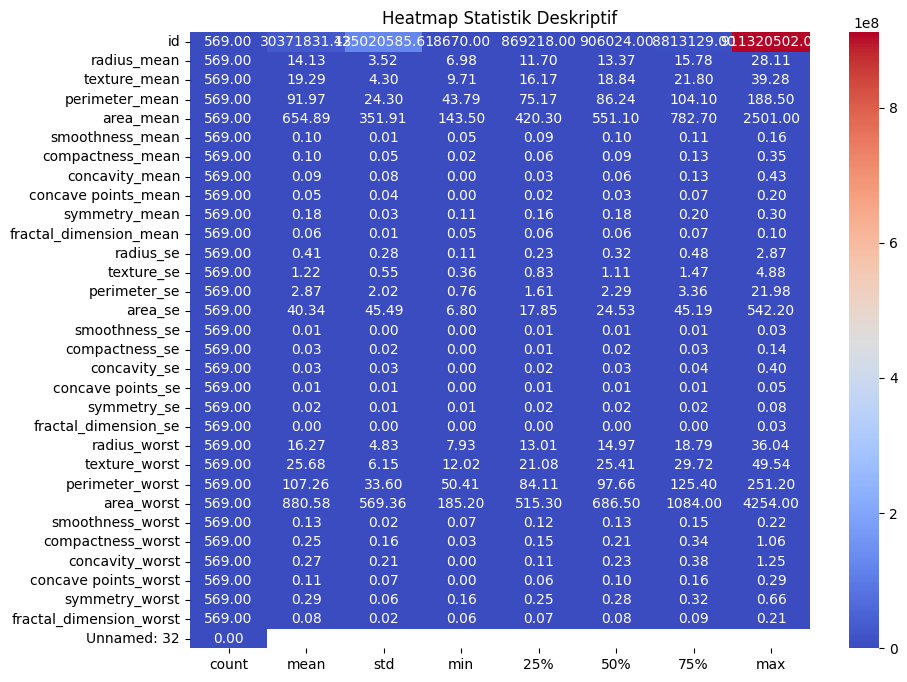


Distribusi Target:
diagnosis
B    357
M    212
Name: count, dtype: int64


<ipython-input-16-86843a1ae07e>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='diagnosis', data=data, palette="Set2")


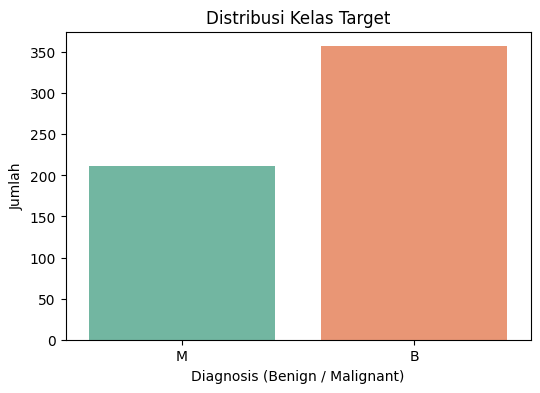

<ipython-input-16-86843a1ae07e>:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_values.index, y=missing_values.values, palette="mako")



Missing Values:


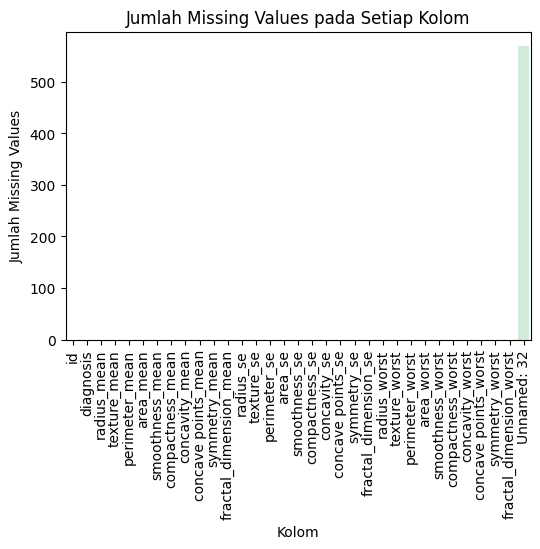


Ukuran Data:
      Dataset  Jumlah Sampel  Jumlah Fitur
0  Data Latih            455            30
1    Data Uji            114            30


<ipython-input-16-86843a1ae07e>:89: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Dataset", y="Jumlah Sampel", data=data_sizes, palette="viridis")


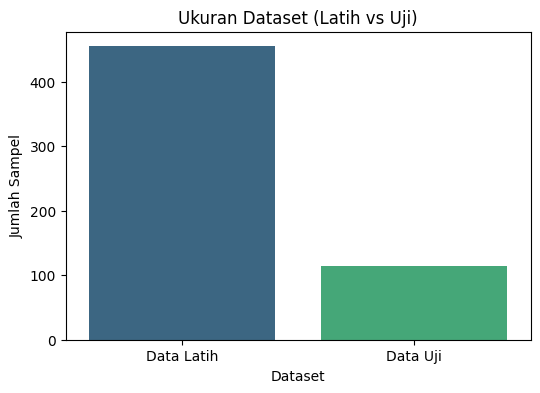

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
file_path = 'Cancer_Data.csv'
data = pd.read_csv(file_path)

# Informasi dataset
print("Informasi Dataset:")
data.info()

# Statistik deskriptif dataset
print("\nStatistik Deskriptif:")
print(data.describe())

# Visualisasi statistik deskriptif dengan heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(data.describe().transpose(), annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Heatmap Statistik Deskriptif")
plt.show()

# Distribusi target
print("\nDistribusi Target:")
print(data['diagnosis'].value_counts())

# Visualisasi distribusi target
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=data, palette="Set2")
plt.title('Distribusi Kelas Target')
plt.xlabel("Diagnosis (Benign / Malignant)")
plt.ylabel("Jumlah")
plt.show()

# Mengecek missing values
print("\nMissing Values:")
missing_values = data.isnull().sum()

# Visualisasi missing values
if missing_values.sum() > 0:
    plt.figure(figsize=(6, 4))
    sns.barplot(x=missing_values.index, y=missing_values.values, palette="mako")
    plt.xticks(rotation=90)
    plt.title("Jumlah Missing Values pada Setiap Kolom")
    plt.ylabel("Jumlah Missing Values")
    plt.xlabel("Kolom")
    plt.show()
else:
    print("Tidak ada missing values.")

# Menghapus kolom yang tidak diperlukan
if 'Unnamed: 32' in data.columns:
    data = data.drop(columns=['Unnamed: 32'])
if 'id' in data.columns:
    data = data.drop(columns=['id'])

# Proses Features Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

# Encoding target
label_encoder = LabelEncoder()
data['diagnosis'] = label_encoder.fit_transform(data['diagnosis'])

# Memisahkan fitur dan target
X = data.drop(columns=['diagnosis'])
y = data['diagnosis']

# Membagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standarisasi fitur
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Menampilkan ukuran data dengan tabel
print("\nUkuran Data:")
data_sizes = pd.DataFrame({
    "Dataset": ["Data Latih", "Data Uji"],
    "Jumlah Sampel": [X_train.shape[0], X_test.shape[0]],
    "Jumlah Fitur": [X_train.shape[1], X_test.shape[1]]
})
print(data_sizes)

# Visualisasi ukuran data dengan bar plot
plt.figure(figsize=(6, 4))
sns.barplot(x="Dataset", y="Jumlah Sampel", data=data_sizes, palette="viridis")
plt.title("Ukuran Dataset (Latih vs Uji)")
plt.ylabel("Jumlah Sampel")
plt.xlabel("Dataset")
plt.show()


4. **Proses Learning / Modeling**



Evaluasi Model:
Akurasi: 0.96

Laporan Klasifikasi:
               precision    recall  f1-score     support
Benign         0.958904  0.985915  0.972222   71.000000
Malignant      0.975610  0.930233  0.952381   43.000000
accuracy       0.964912  0.964912  0.964912    0.964912
macro avg      0.967257  0.958074  0.962302  114.000000
weighted avg   0.965205  0.964912  0.964738  114.000000


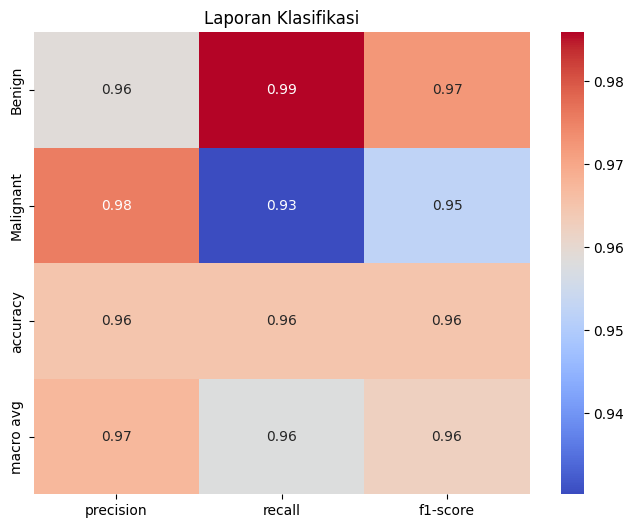

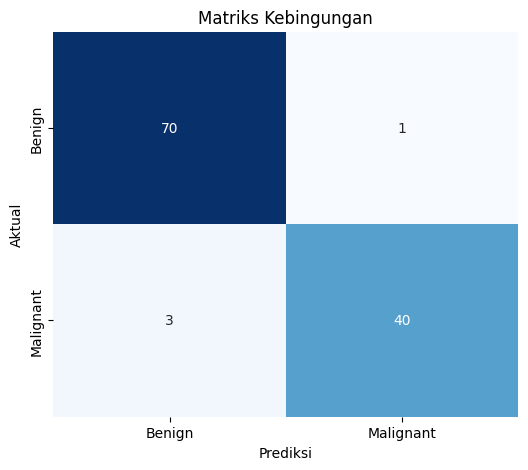

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import pandas as pd

# Membuat model Random Forest
model = RandomForestClassifier(random_state=42)

# Melatih model dengan data latih
model.fit(X_train, y_train)

# Melakukan prediksi pada data uji
y_pred = model.predict(X_test)

# Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
print("\nEvaluasi Model:")
print(f"Akurasi: {accuracy:.2f}")

# Laporan klasifikasi
report = classification_report(y_test, y_pred, target_names=['Benign', 'Malignant'], output_dict=True)
classification_df = pd.DataFrame(report).transpose()
print("\nLaporan Klasifikasi:\n", classification_df)

# Visualisasi laporan klasifikasi
plt.figure(figsize=(8, 6))
sns.heatmap(classification_df.iloc[:-1, :-1], annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Laporan Klasifikasi")
plt.show()

# Menampilkan matriks kebingungan
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualisasi matriks kebingungan
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title('Matriks Kebingungan')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()


5. **Performa Model**

Performa Model :
- Akurasi: Mengukur seberapa sering model membuat prediksi yang benar.
- Laporan klasifikasi: Memberikan metrik seperti precision, recall, dan f1-score untuk masing-masing kelas.
- Matriks kebingungan: Visualisasi performa model dalam memprediksi setiap kelas.


Performa Model:
Akurasi: 0.96

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



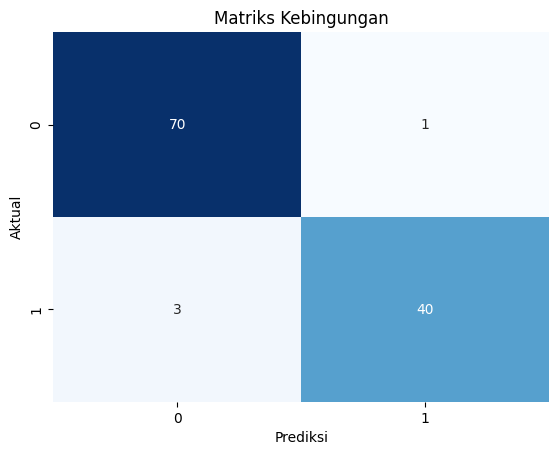

In [9]:
# Menampilkan hasil evaluasi
print("\nPerforma Model:")
print(f"Akurasi: {accuracy_score(y_test, y_pred):.2f}")
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriks Kebingungan')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

6. **Diskusi Hasil dan Kesimpulan**

Diskusi Hasil:
- Model Random Forest menunjukkan performa akurasi tinggi, dengan laporan klasifikasi yang menunjukkan precision, recall, dan F1-score memuaskan.
- Matriks kebingungan memperlihatkan distribusi prediksi yang baik.

Kesimpulan:
- Model dapat digunakan untuk membantu mendeteksi jenis kanker berdasarkan data karakteristik pasien.
- Model ini cukup andal untuk digunakan dalam tugas klasifikasi kanker. Namun, untuk lebih meningkatkan kinerja model, langkah tambahan seperti validasi silang atau pengoptimalan hyperparameter dapat dipertimbangkan.